In [214]:
import numpy as np
import pandas as pd
import random
from random import randint
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

In [122]:
def weighted_median_general(data, weights):
    # Pair each data point with its weight and sort by data point
    data_weights = sorted(zip(data, weights))
    
    total_weight = sum(weights)
    cumulative_weight = 0.0
    
    for value, weight in data_weights:
        cumulative_weight += weight
        if cumulative_weight >= total_weight / 2.0:
            return value
    
    # If for some reason the loop completes without returning, return the last value
    return data[-1]
def weighted_median(data, weights):
    max_n = 1005
    m = len(data)
    cc = [0.0]*(max_n+1)
    for i in range(m):
        if data[i]>max_n:
            cc[max_n] += weights[i]
        else:
            cc[data[i]] += weights[i]
    w = 0
    tot_weight = sum(cc) * 0.5
    for i in range(max_n+1):
        w += cc[i]
        if w>tot_weight:
            return i
def plot_series(arr):
    plt.plot(arr)
    plt.show()
def plot_dist(arr):
    plt.hist(arr, bins=np.arange(min(arr), max(arr)+1), edgecolor='black')
    plt.show()
fac_max = 155
fac=[1]
for i in range(1,fac_max):
    fac.append(fac[-1]*i)
ffac = np.array(fac).astype(float)
binom_mat = np.zeros((fac_max,fac_max))
for i in range(fac_max):
    for j in range(fac_max):
        binom_mat[i,j] = fac[i]/(fac[j]*fac[i-j])
def get_fac(n):
    #return fac[n]
    return ffac[n]
def binom(n,m):
    #return (fac[n])//(fac[m]*fac[n-m])
    #return get_fac(n)/(get_fac(m)*get_fac(n-m))
    return binom_mat[n,m]
def find_list_median(numbers):
    sorted_numbers = sorted(numbers)
    n = len(sorted_numbers)
    mid = n // 2
    return (sorted_numbers[mid] + sorted_numbers[~mid]) / 2
def apply_bounds(value, lower_bound, upper_bound):
    return max(lower_bound, min(value, upper_bound))
def get_game_value():
    di=100
    while di>10 or bo>12 or bo<2:
        t1=randint(2,22)
        t2=randint(2,int( (100-t1)/4 + 2 )  )
        t3=randint(1,int( (100-t1-t2)/3 + 1 )  )
        t4=randint(0,int( (100-t1-t2-t3)/2  )  )
        t5=randint(0,int( (100-t1-t2-t3-t4)  )  )
        di,bo,g,s,br = sorted([t1,t2,t3,t4,t5])
    return ([br,s,g,bo,di])
def get_yield_by_picked(picked):
    return ( (picked[0]*2+picked[1]*5+picked[2]*10)*(2**picked[4]) )  
def sample_picked_once(game_value):
    left = game_value.copy()
    picked = [0]*5
    while(sum(left)>=1 and picked[3]<2):
        now = random.choices(list(range(5)), left, k=1)[0]
        left[now] -= 1
        picked[now] += 1
    return picked
def sample_yield_once(game_value):
    picked = sample_picked_once(game_value)
    return get_yield_by_picked(picked)
def sample_median(game_value):
    lst = []
    for i in range(1000000):
        lst.append( sample_yield_once(game_value) )
    return find_list_median(lst)
def count_realization(type_value,game_value):
    type_sum = sum(type_value)
    uni_sum = sum(game_value)
    res = 1.0
    for i in range(5):
        res=res*binom(game_value[i],type_value[i])
    res=res/binom(uni_sum,type_sum)
    res=res*2.0/type_sum
    return res
def get_ywlst(game_value):
    # lack  * 2.0 * binom(game_value[3],2)
    res = []
    uni_sum = sum(game_value)
    type_sum = 2
    y = 0
    for br in range(game_value[0]+1):
        y = y + br*2
        type_sum = type_sum + br
        wbr = binom(game_value[0],br)
        for s in range(game_value[1]+1):
            y = y + s*5
            type_sum = type_sum + s
            ws = wbr * binom(game_value[1],s)
            for g in range(game_value[2]+1):
                y = y + g*10
                type_sum = type_sum + g
                wg = ws * binom(game_value[2],g)
                yy = y
                for di in range(game_value[4]+1):
                    type_sum = type_sum + di
                    now = [br,s,g,2,di]
                    w =  wg * binom(game_value[4],di) / ( binom(uni_sum,type_sum)*type_sum )
                    res.append((yy,w))
                    yy = yy*2
                    type_sum = type_sum - di
                y = y - g*10
                type_sum = type_sum -g
            y = y - s*5
            type_sum = type_sum - s
        y = y - br*2
        type_sum = type_sum - br
    return res
def get_ywlst_oldversion(game_value):
    res = []
    for br in range(game_value[0]+1):
        for s in range(game_value[1]+1):
            for g in range(game_value[2]+1):
                for di in range(game_value[4]+1):
                    now = [br,s,g,2,di]
                    w = count_realization(now,game_value)
                    y = get_yield_by_picked(now)
                    res.append((y,w))
    return res
def get_median_by_ywlst(game_value):
    ywlst = get_ywlst(game_value)
    #sorted_ywlist = sorted(ywlst)
    list_of_tuple = tuple(map(list, zip(*ywlst)))
    ylst = list_of_tuple[0]
    wlst = list_of_tuple[1]
    return weighted_median(ylst,wlst)

In [5]:
#lst = [1,2,1,3,1]
#print(  get_ywlst(lst)  )
#print(  get_ywlst_oldversion(lst)  )

In [6]:
lst = [31,41,31,13,31]

In [11]:
x = get_ywlst(lst)

In [8]:
x = get_ywlst_oldversion(lst)

In [17]:
get_median_by_ywlst([11,11,10,9,8])

74

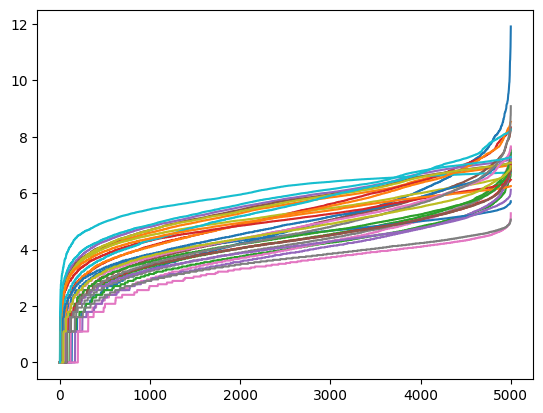

[]
[]


In [89]:
game_value = get_game_value()
arr = []
medlst = []
for i in range(30):
    arr = []
    game_value = get_game_value()
    #med = get_median_by_ywlst(game_value)
    #medlst.append(med)
    #print(game_value)
    for j in range(5000):
        picked = sample_picked_once(game_value)
        arr.append((picked[0]*2 + picked[1]*5 + picked[2]*10)*(2**picked[4]))
    arr = np.array(arr)
    #arr[arr>500]=500
    #arr = arr/500.0
    #arr = arr**0.5
    arr=np.log(arr+1)
    #arr=1.0/(1.0+np.exp(  (arr-np.log(100))*1.0  ))
    #arr[arr>6]=5.0+np.log(arr[arr>6]-5.0)
    #arr[arr<4]=5.0-np.log(5.0-arr[arr<4])
    #arr[arr<3]=3
    #arr[arr>6.2]=6.2
    #e^4.6=100
    arr = sorted(arr)
    plt.plot(arr)
plt.show()
ar = np.array(medlst)
print(ar)
print(np.log(ar))

#plot_series(arr)
#plot_dist(arr)

In [59]:
def get_penalty(fun_lst,fun_name=None):
    m = len(fun_lst)
    n=7
    sv = {}
    for i in range(m):
        for j in range(3):
            sv[(i,j)]=0
    penal = [0] * m
    pel = np.zeros(30)
    for i in range(3000):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(30):
            bid = []
            for k in range(m):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = fun_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            last_yield = sample_yield_once(game_value)
            last_total_bid = sum(bid)
            for k in range(m):
                penal[k] = penal[k] + abs(med - bid[k]*n)
            pel[j] = pel[j] + abs(med - bid[0]*n)
        if i%50==49:
            print(penal)
            if fun_name is not None:
                print(fun_name[penal.index(min(penal))])
            plot_series(pel)
def Simulation(player_lst):
    n = len(player_lst)
    sv = {}
    for i in range(n):
        for j in range(3):
            sv[(i,j)]=0
    score = [0] * n
    penal = [0] * n
    pel = np.zeros(30)
    for i in range(3000):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(30):
            bid = []
            for k in range(n):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = player_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            last_yield = sample_yield_once(game_value)
            last_total_bid = sum(bid)
            if last_total_bid<=last_yield:
                for k in range(n):
                    score[k] = score[k] + bid[k]
            else:
                for k in range(n):
                    score[k] = score[k] - bid[k]
            for k in range(n):
                penal[k] = penal[k] + abs(med - bid[k]*n)
            pel[j] = pel[j] + abs(med - bid[0]*n)
        if i%1000==999:
            print(score)
            print(penal)
            plot_series(pel)

In [263]:
def generate_dpoints(num_steps, num_samples=100, lowlst = [0.0], highlst = [100.0], shiftlst = [0.0], cilst = [2.0]):
    columns = ['median']
    for j in range(1,num_steps+1):
        strave = 'logave'+str(j)
        strstd = 'logavex'+str(j)
        for low_bound in lowlst:
            for high_bound in highlst:
                for shift_value in shiftlst:
                    for ci_value in cilst:
                        now_low = round(low_bound,2)
                        now_high = round(high_bound,2)
                        now_shift = round(shift_value,2)
                        now_ci = round(ci_value,2)
                        suff = '_' + str(now_low).replace('.', 'x') + '_' + str(now_high).replace('.', 'x') + \
                                '_' + (str(now_shift).replace('.', 'x')).replace('-', 'y') + '_' + str(now_ci).replace('.', 'x')
                        columns.append(strave+suff)
                        columns.append(strstd+suff)
        
    df = pd.DataFrame(columns=columns)
    #print(df)
    cnt = len(lowlst) * len(highlst) * len(shiftlst) * len(cilst) * 2
    for i in range(num_samples):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        for k in range(50):
            lst = [0.0]*cnt
            for j in range(1,num_steps+1):
                y = sample_yield_once(game_value)
                z = np.log(y+1)
                for low_bound in lowlst:
                    for high_bound in highlst:
                        for shift_value in shiftlst:
                            for ci_value in cilst:
                                now_low = round(low_bound,2)
                                now_high = round(high_bound,2)
                                now_shift = round(shift_value,2)
                                now_ci = round(ci_value,2)
                                zz = apply_bounds(z,now_low,now_high) - now_shift
                                lst.append(lst[-cnt]+zz)
                                lst.append((lst[-cnt]**now_ci+abs(zz)**now_ci)**(1.0/now_ci))
            df.loc[len(df)] = ([np.log(med+1)]+lst[cnt:])
        if i%50==49:
            print(i)
    return df

49
99
149
199


C:\Users\zhiha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


[43998, 42212, 42647, 43774, 41482, 42022, 43081, 40597, 41196, 41798, 39550, 40109, 46842, 44542, 44004, 43944, 44880, 42622, 42358, 42390]
(3.5, 7.0)


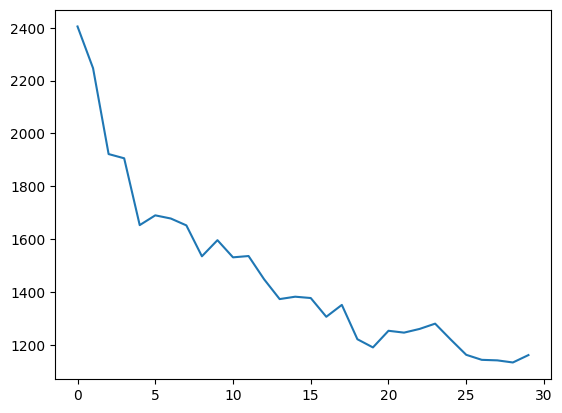

[90182, 86102, 86898, 89962, 85697, 86829, 89529, 85585, 86982, 88603, 85718, 87422, 96786, 92451, 91352, 91304, 93983, 89753, 88854, 88985]
(3.0, 7.0)


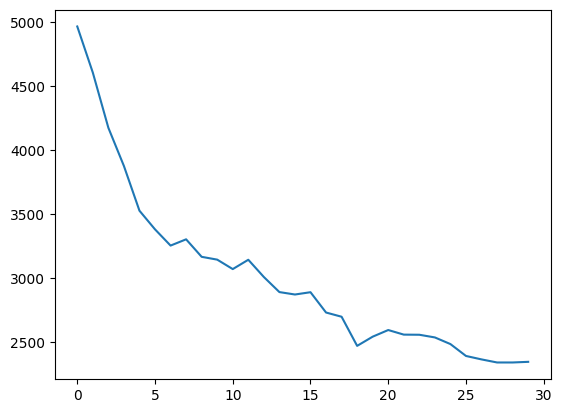

[126355, 124608, 125591, 126109, 123793, 124918, 125464, 123233, 124730, 124013, 122906, 124739, 135344, 130363, 128948, 128940, 131081, 126512, 125454, 125660]
(3.5, 7.0)


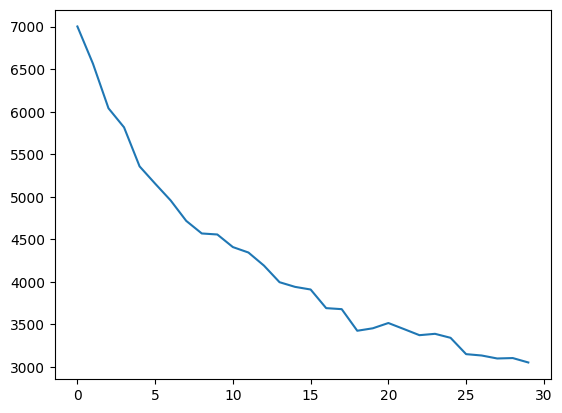

[166837, 164931, 166355, 166536, 164355, 166041, 165683, 164170, 166503, 164877, 165486, 168425, 177792, 171709, 170107, 170091, 172008, 166588, 165329, 165740]
(3.0, 7.0)


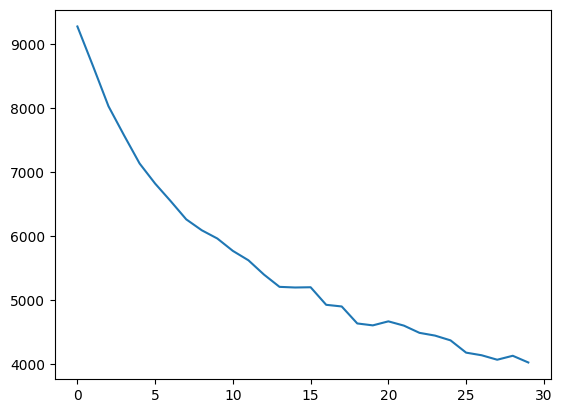

[214602, 211710, 213896, 214362, 211546, 213939, 213416, 211299, 214420, 212849, 212878, 216275, 225759, 218557, 216949, 217409, 218510, 212326, 211241, 212085]
old_(3.1, 7.5)


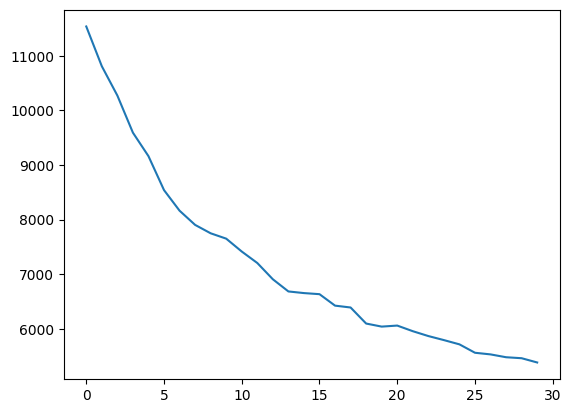

[283309, 276206, 277193, 282441, 275116, 276425, 280190, 273063, 276195, 277735, 274035, 279075, 299203, 288440, 284613, 284516, 290650, 281105, 278143, 278370]
(3.0, 7.0)


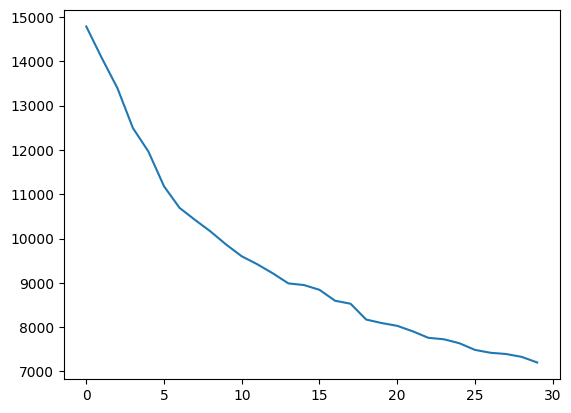

[327181, 319371, 320201, 326107, 317955, 319142, 323422, 315316, 318383, 319746, 314972, 320036, 341724, 330439, 326890, 326922, 332413, 322972, 320315, 320781]
(3.5, 7.0)


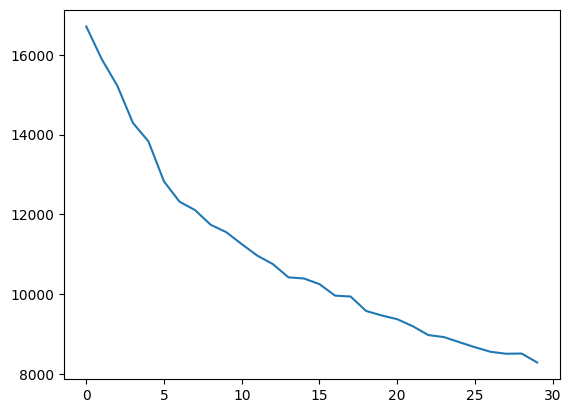

[376007, 365244, 368072, 374566, 363248, 366411, 370591, 359464, 364851, 365586, 358948, 366353, 392456, 378235, 374260, 375431, 382504, 370138, 367308, 368863]
(3.5, 7.0)


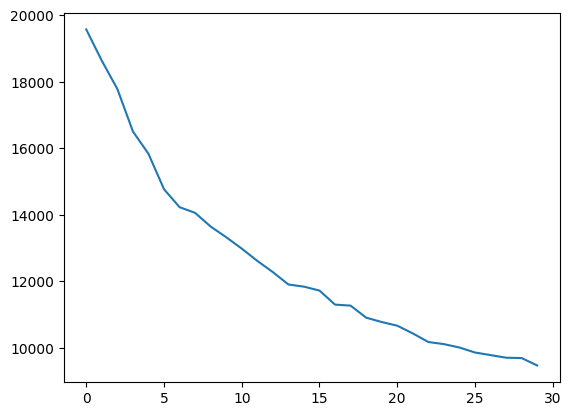

[425601, 414532, 417831, 424082, 412444, 415990, 419789, 408189, 414054, 414245, 407207, 414802, 441664, 427148, 423208, 424895, 430607, 418150, 415634, 417704]
(3.5, 7.0)


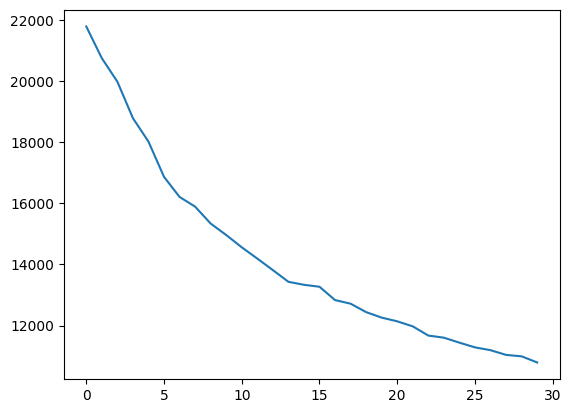

[488303, 478767, 484400, 486331, 476339, 482080, 481350, 471723, 479691, 475040, 470987, 480795, 511105, 495294, 492009, 494370, 499261, 485881, 484317, 487179]
(3.5, 7.0)


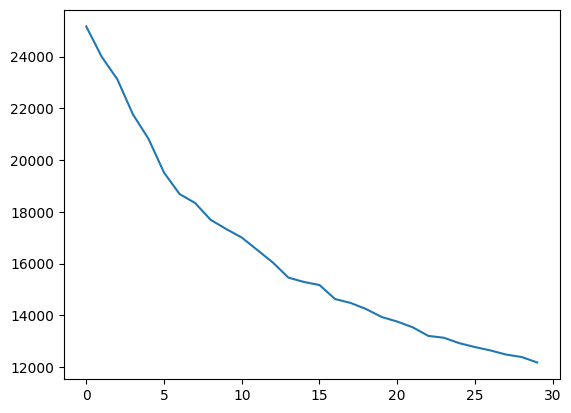

[539083, 528869, 535521, 537130, 526426, 533100, 532020, 521621, 530350, 525260, 520283, 530737, 563591, 546331, 542934, 545644, 550581, 535887, 534305, 537462]
(3.5, 7.0)


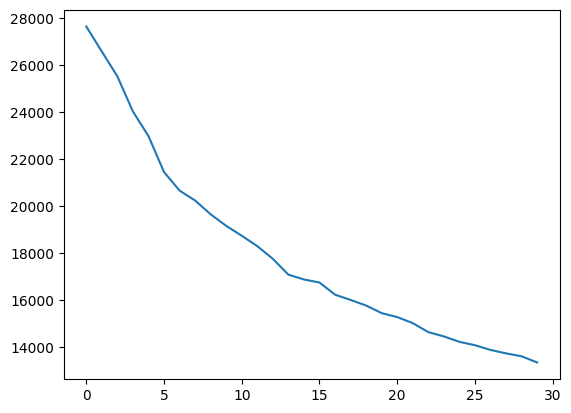

[608529, 597132, 605150, 605847, 593589, 601391, 599694, 587655, 597418, 592421, 587771, 598942, 636817, 617414, 614595, 617618, 622909, 606487, 605683, 609197]
(3.0, 7.0)


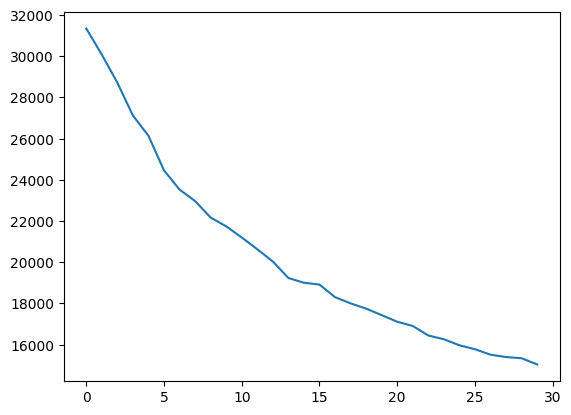

[654057, 639065, 647933, 650996, 635259, 643966, 644036, 628964, 639600, 635704, 628755, 640882, 681538, 659434, 655904, 659122, 667116, 648341, 647096, 650932]
(3.5, 7.0)


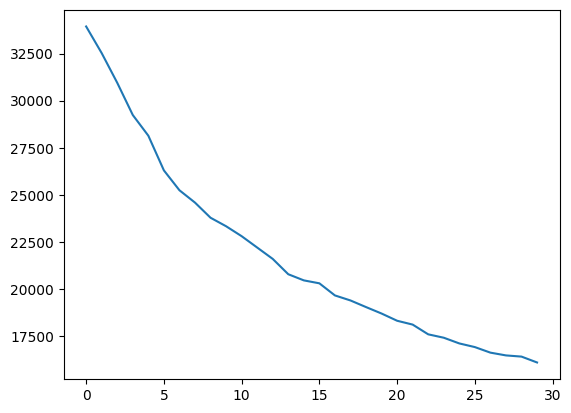

[694485, 680867, 690866, 691511, 677509, 687238, 684704, 672131, 684042, 677094, 673193, 686798, 725435, 702018, 698319, 702093, 710134, 690224, 688981, 693286]
(3.0, 7.0)


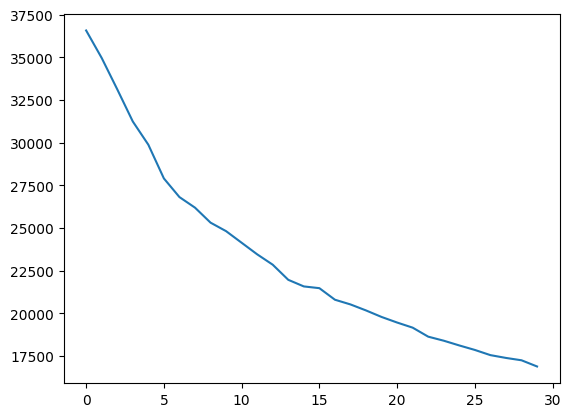

[745603, 732236, 741957, 742162, 728318, 737848, 734684, 722443, 734134, 726618, 724090, 737639, 782019, 757195, 752912, 756499, 765855, 744771, 742994, 747044]
(3.0, 7.0)


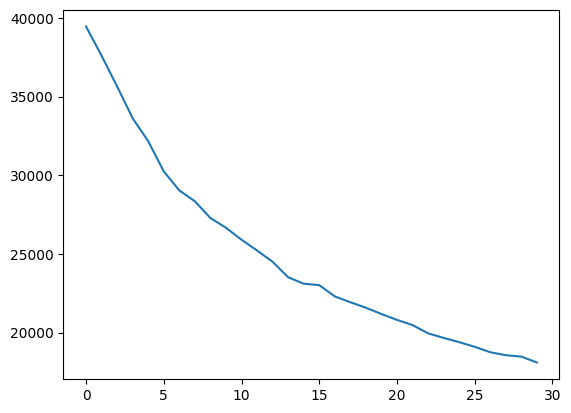

[799112, 785057, 796014, 795297, 780409, 791277, 786728, 773640, 786485, 777574, 774805, 789387, 835433, 809949, 806118, 809976, 818682, 797100, 796001, 800449]
(3.0, 7.0)


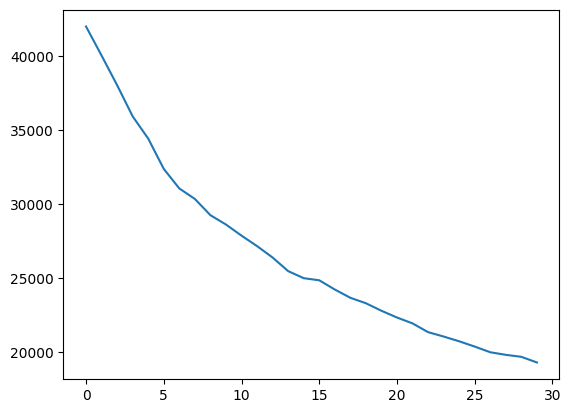

[858764, 843321, 855545, 854353, 837486, 849704, 844163, 829616, 843253, 832700, 829884, 845457, 899125, 872034, 868483, 872584, 881097, 858295, 857571, 862333]
(3.0, 7.0)


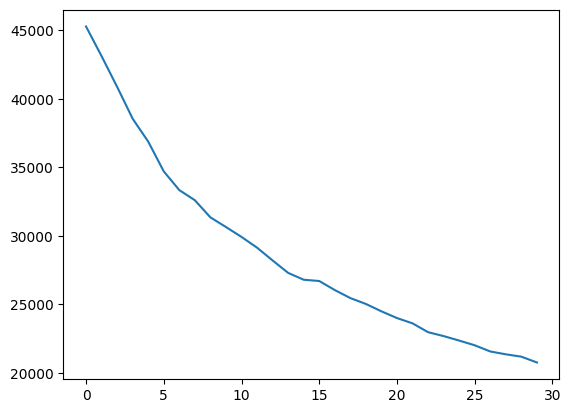

[902600, 888206, 901303, 898211, 882327, 895420, 888117, 874572, 888924, 876818, 875114, 891636, 946655, 918430, 914728, 919006, 927324, 903583, 902958, 907981]
(3.0, 7.0)


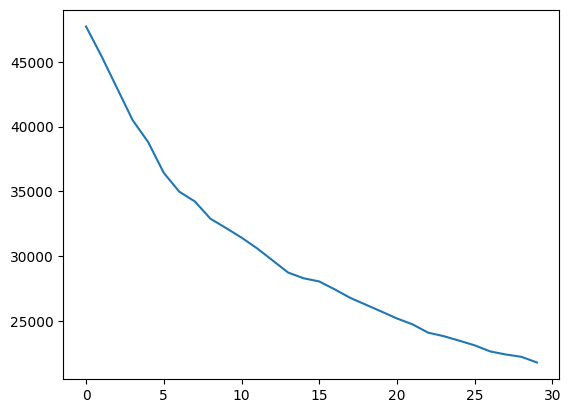

[957414, 943597, 958018, 952213, 936802, 951314, 940928, 927940, 943633, 928562, 928434, 946389, 1006945, 976845, 973486, 978305, 986625, 961366, 961213, 966915]
(3.0, 7.0)


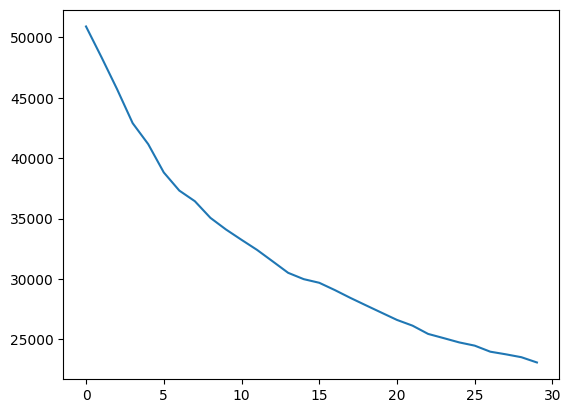

[1005164, 987548, 1002201, 999738, 980521, 995094, 987993, 971859, 987358, 974969, 973711, 991822, 1063342, 1028875, 1023706, 1027904, 1041019, 1011414, 1009448, 1014595]
(3.0, 7.0)


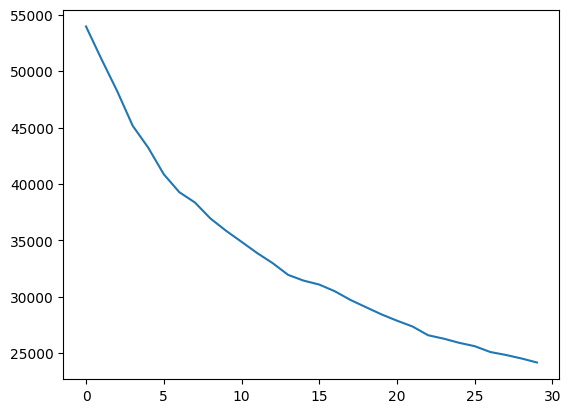

[1064257, 1045031, 1060585, 1058624, 1038014, 1053142, 1046687, 1028864, 1045176, 1033292, 1030499, 1049262, 1123686, 1087657, 1082458, 1087031, 1100901, 1070033, 1068005, 1073511]
(3.0, 7.0)


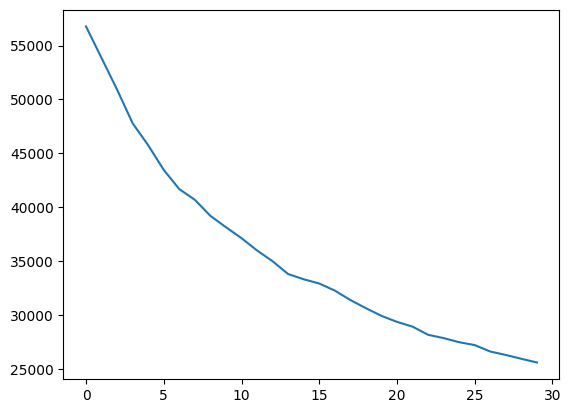

[1102928, 1083138, 1099422, 1097257, 1076108, 1091790, 1085293, 1066821, 1083632, 1071132, 1067628, 1086691, 1164505, 1126860, 1121424, 1125922, 1140270, 1107856, 1105942, 1111519]
(3.0, 7.0)


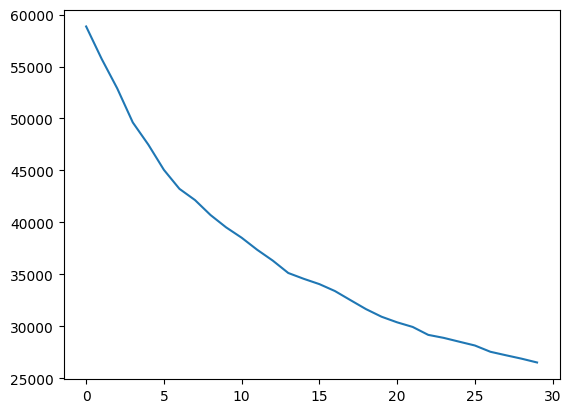

[1146503, 1125966, 1143250, 1140537, 1118696, 1135475, 1128428, 1109581, 1127382, 1114287, 1110759, 1131127, 1212262, 1172728, 1166824, 1171344, 1186951, 1152844, 1150382, 1156060]
(3.0, 7.0)


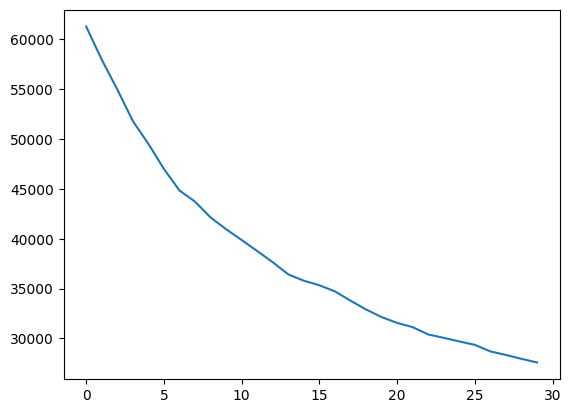

[1191012, 1171177, 1190063, 1185111, 1163929, 1182232, 1172846, 1154698, 1173884, 1158388, 1155505, 1176938, 1261415, 1220741, 1215168, 1220127, 1234070, 1199080, 1196949, 1203134]
(3.0, 7.0)


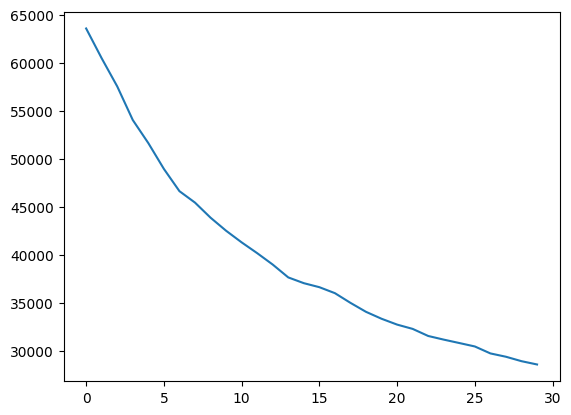

[1242364, 1223518, 1245612, 1236065, 1215657, 1236824, 1223259, 1206168, 1227835, 1208606, 1207735, 1231477, 1320934, 1278086, 1272968, 1278650, 1292090, 1255375, 1253748, 1260800]
(3.0, 7.0)


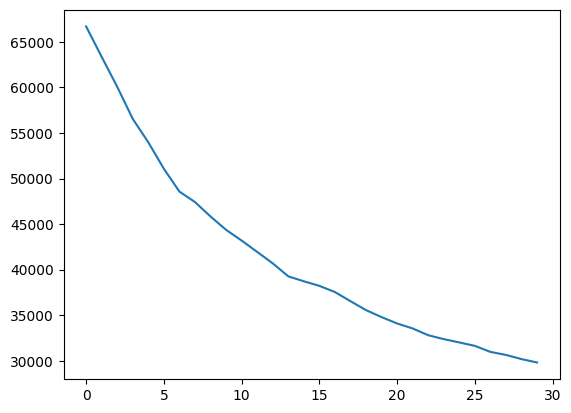

[1300674, 1280613, 1302633, 1293851, 1271977, 1293428, 1280314, 1261677, 1283728, 1265508, 1263809, 1288152, 1384159, 1339350, 1333217, 1338872, 1354761, 1316442, 1313965, 1321115]
(3.0, 7.0)


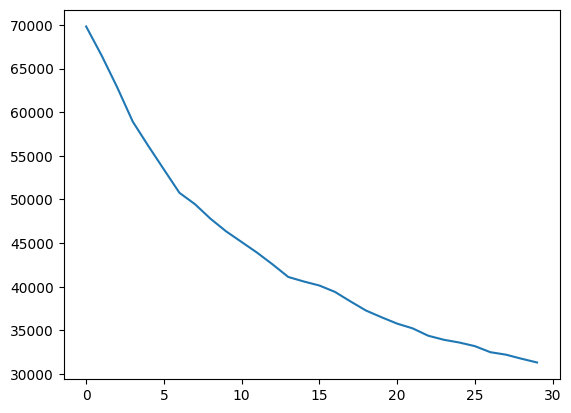

[1339144, 1319549, 1342303, 1332315, 1310663, 1332642, 1318202, 1299855, 1322457, 1303291, 1301907, 1326831, 1421763, 1376719, 1370914, 1376859, 1391678, 1353252, 1351261, 1358848]
(3.0, 7.0)


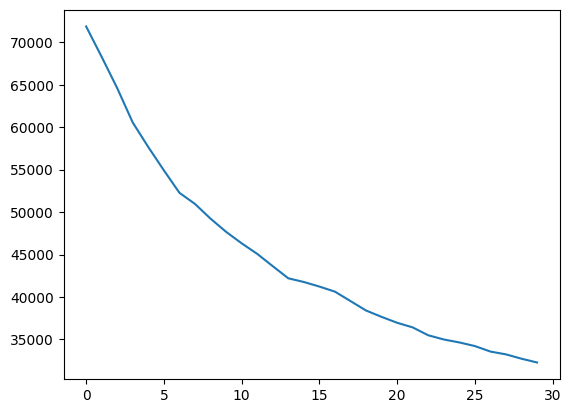

[1377796, 1358549, 1381487, 1370728, 1349271, 1371512, 1356255, 1338317, 1361159, 1341379, 1340661, 1365789, 1463040, 1416659, 1410637, 1416543, 1432292, 1392957, 1390878, 1398436]
(3.0, 7.0)


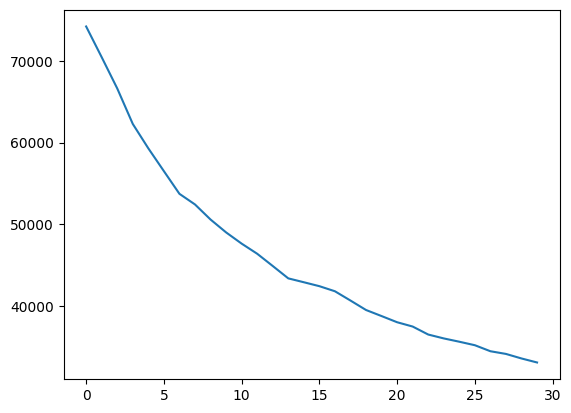

[1428397, 1405587, 1429702, 1420882, 1395626, 1418881, 1405685, 1385044, 1408722, 1388969, 1387997, 1413842, 1514004, 1465833, 1459942, 1466398, 1482332, 1441273, 1439461, 1447759]
(3.0, 7.0)


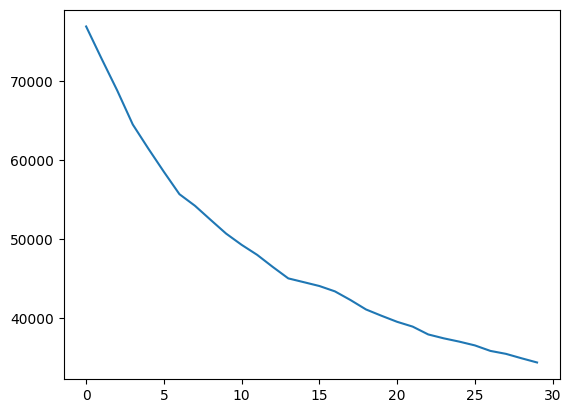

[1468792, 1445493, 1469937, 1461145, 1435315, 1458824, 1445489, 1424726, 1448772, 1427949, 1427956, 1454484, 1560124, 1509967, 1503339, 1509765, 1527109, 1484500, 1482251, 1490536]
(3.0, 7.0)


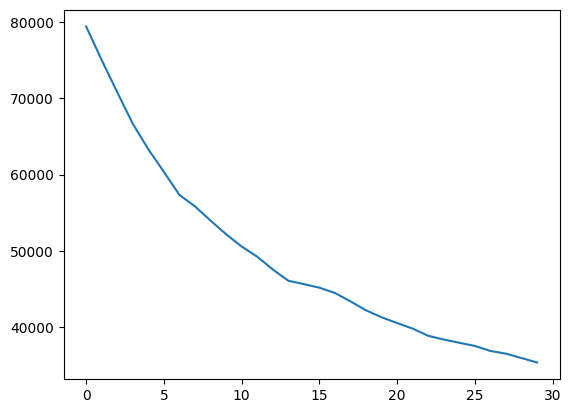

[1520508, 1496716, 1521977, 1512674, 1486798, 1511039, 1496981, 1476634, 1501453, 1480738, 1481869, 1509033, 1616829, 1565160, 1558535, 1565319, 1582403, 1538511, 1536295, 1544972]
(3.0, 7.0)


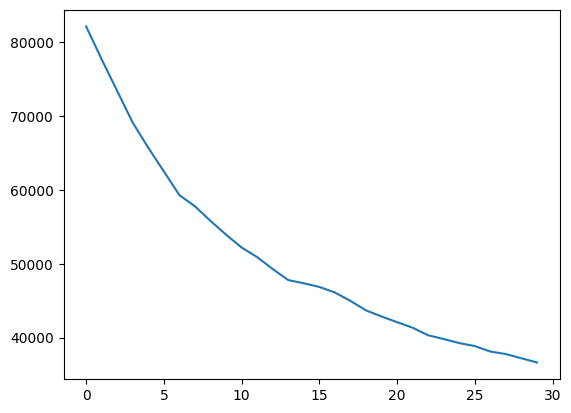

[1573148, 1547329, 1574567, 1565045, 1537293, 1563608, 1548344, 1526880, 1554073, 1530465, 1532941, 1562907, 1676922, 1621487, 1613208, 1620387, 1640668, 1593061, 1589416, 1598621]
(3.0, 7.0)


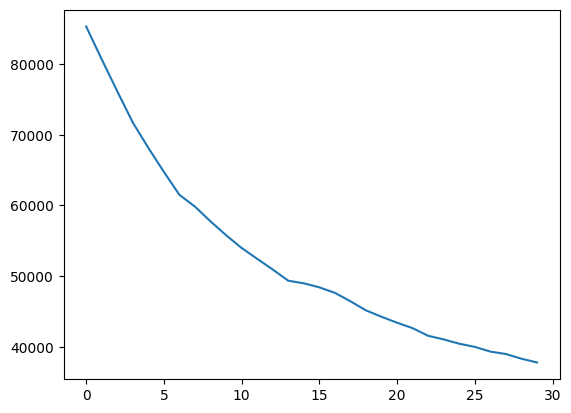

[1611808, 1585383, 1614001, 1603619, 1575575, 1602990, 1587582, 1565813, 1593982, 1570716, 1573296, 1604264, 1718759, 1662102, 1653870, 1661477, 1681732, 1633042, 1629728, 1639592]
(3.0, 7.0)


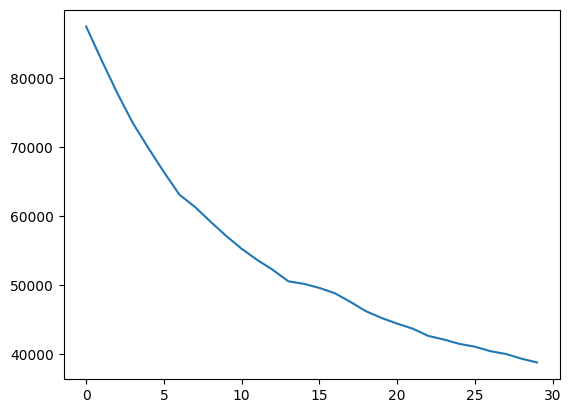

[1669935, 1640528, 1669126, 1661341, 1630155, 1657702, 1644473, 1619855, 1648156, 1626398, 1626868, 1658120, 1781852, 1722857, 1713971, 1721331, 1743655, 1692886, 1688982, 1698633]
(3.0, 7.0)


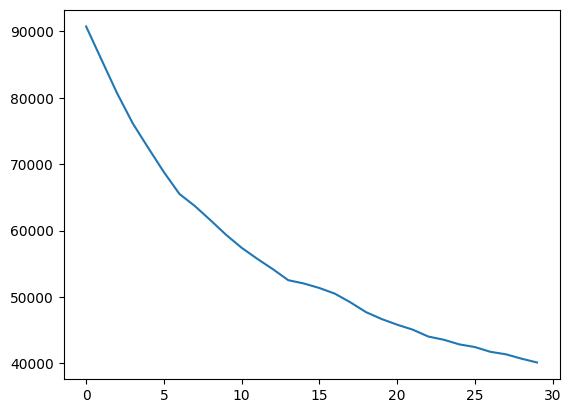

[1719241, 1689025, 1717826, 1710627, 1678614, 1706336, 1694026, 1668406, 1696820, 1676287, 1675379, 1706448, 1836013, 1775140, 1765665, 1773044, 1796456, 1743972, 1739748, 1749516]
(3.0, 7.0)


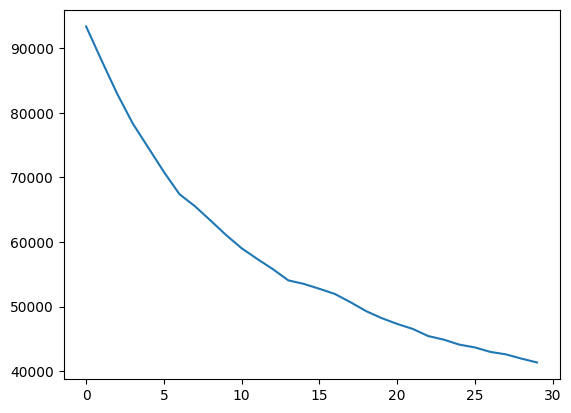

[1761046, 1731773, 1761521, 1752004, 1720859, 1749337, 1735192, 1710858, 1739816, 1717764, 1719271, 1750806, 1885045, 1823018, 1813665, 1821089, 1844284, 1790846, 1786676, 1796592]
(3.0, 7.0)


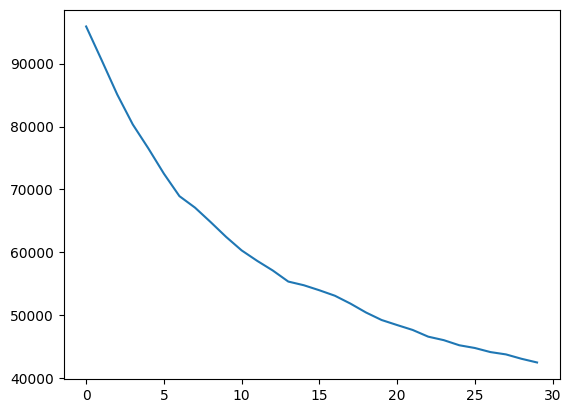

[1801838, 1770976, 1800684, 1792918, 1759897, 1788274, 1775785, 1749470, 1778361, 1758078, 1757312, 1788799, 1922837, 1860595, 1851422, 1859039, 1881243, 1827848, 1823872, 1834057]
(3.0, 7.0)


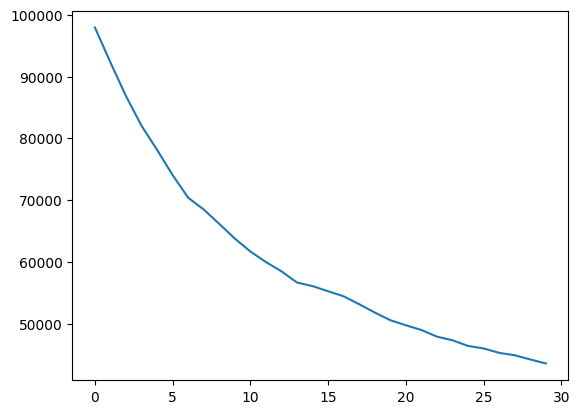

[1858693, 1825212, 1857660, 1849009, 1813573, 1844722, 1830723, 1802527, 1834535, 1812175, 1811022, 1845765, 1980175, 1915486, 1906710, 1915019, 1937604, 1882155, 1878681, 1889688]
(3.0, 7.0)


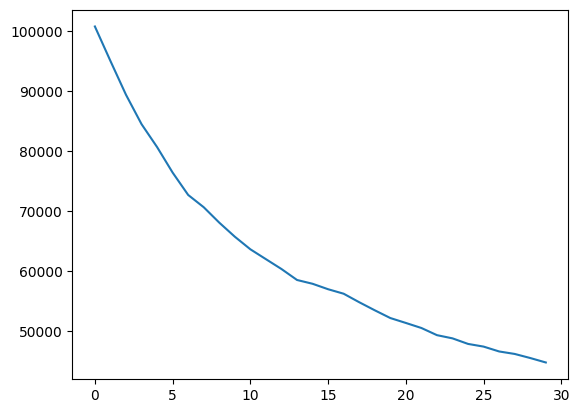

[1910422, 1876259, 1911126, 1900277, 1863357, 1896811, 1880819, 1850646, 1884440, 1861246, 1858035, 1893958, 2038275, 1972082, 1963948, 1972947, 1994734, 1937922, 1935310, 1947042]
(3.0, 7.0)


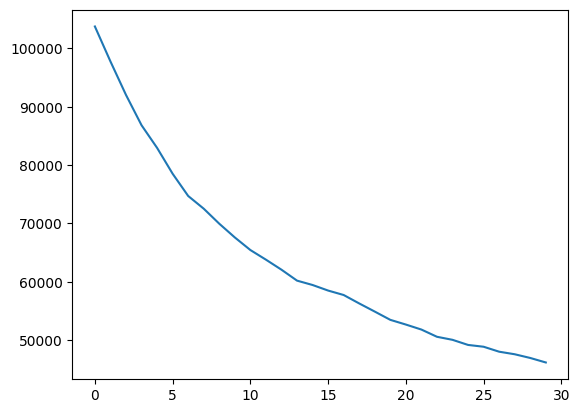

[1955546, 1921711, 1957985, 1944936, 1908426, 1943065, 1924363, 1895581, 1930456, 1903714, 1903094, 1940063, 2084027, 2016858, 2009090, 2018758, 2039305, 1981729, 1979743, 1992092]
(3.0, 7.0)


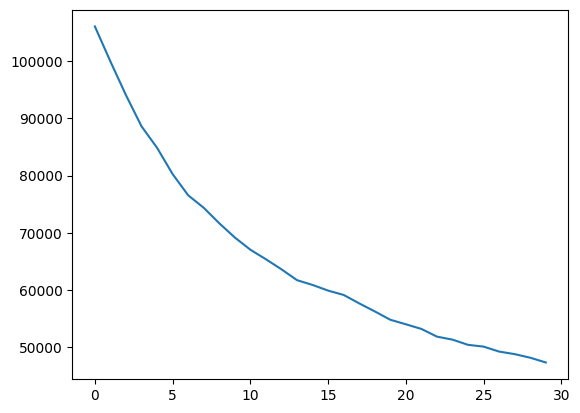

[2005024, 1969724, 2007369, 1994124, 1956247, 1992296, 1973301, 1943293, 1979336, 1952065, 1950202, 1988609, 2138381, 2069148, 2061464, 2071528, 2092494, 2033156, 2031224, 2043952]
(3.0, 7.0)


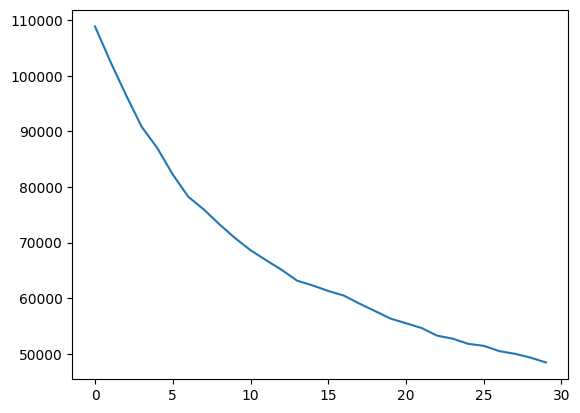

[2054392, 2020378, 2059024, 2043558, 2006941, 2044233, 2022762, 1994181, 2031265, 2001899, 2001783, 2041353, 2187324, 2117685, 2110703, 2121182, 2139876, 2080510, 2079612, 2092808]
(3.0, 7.0)


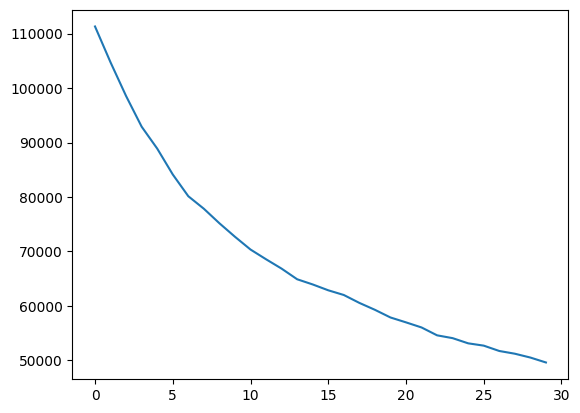

[2088880, 2054606, 2093626, 2078094, 2041320, 2078743, 2057333, 2028726, 2066149, 2037282, 2036993, 2077010, 2221738, 2150953, 2143531, 2153919, 2172387, 2112239, 2111144, 2124321]
(3.0, 7.0)


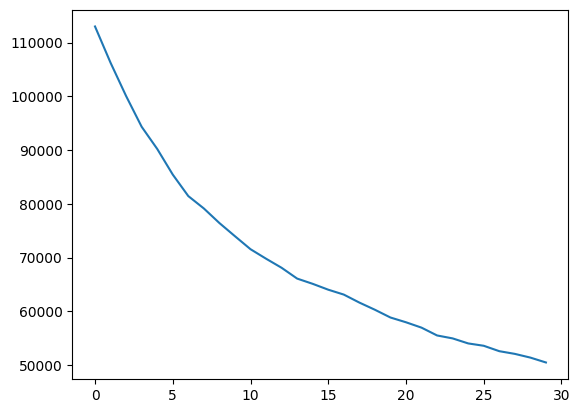

[2150214, 2114270, 2154679, 2138873, 2100335, 2139031, 2117156, 2086433, 2125116, 2094844, 2092668, 2133740, 2289265, 2215818, 2208330, 2219090, 2239227, 2176424, 2175360, 2188920]
(3.0, 7.0)


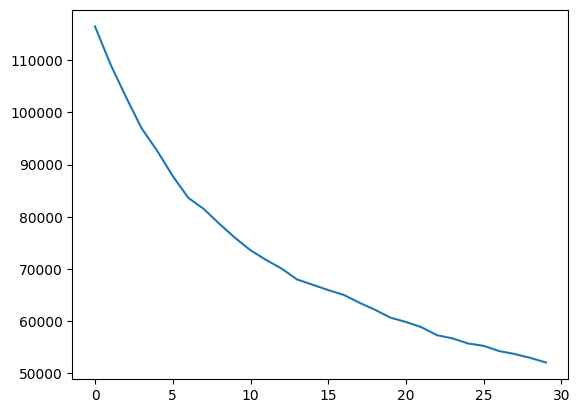

[2217703, 2178191, 2219643, 2205814, 2163189, 2202686, 2182728, 2147834, 2187010, 2158390, 2152095, 2193858, 2366974, 2289999, 2281730, 2292532, 2315416, 2249222, 2247507, 2261129]
(3.0, 7.0)


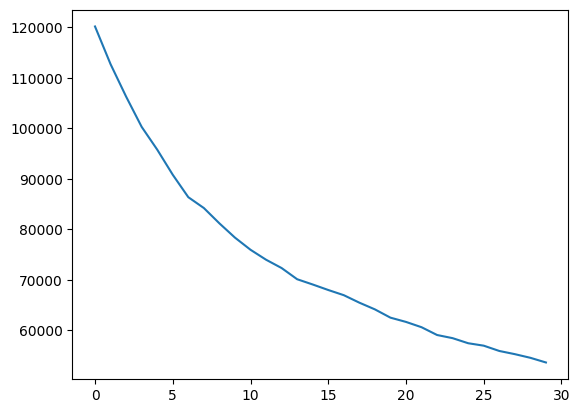

[2274406, 2234726, 2276740, 2262652, 2219967, 2259975, 2239648, 2204971, 2244719, 2215294, 2209522, 2252194, 2427976, 2349045, 2339969, 2350685, 2375026, 2307152, 2304612, 2318231]
(3.0, 7.0)


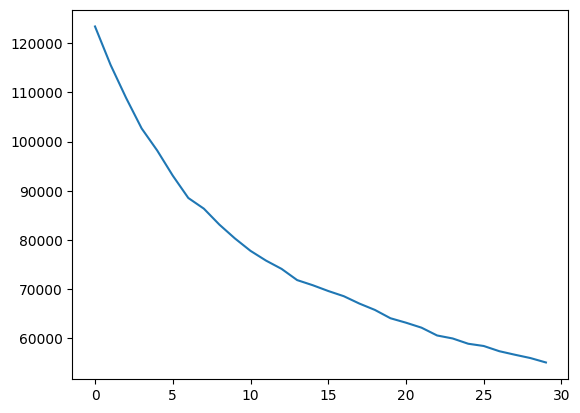

[2318843, 2281724, 2324478, 2306407, 2266278, 2306783, 2282543, 2250419, 2290716, 2256733, 2253638, 2296829, 2476749, 2397546, 2388805, 2399585, 2423199, 2355335, 2353134, 2366933]
(3.0, 7.0)


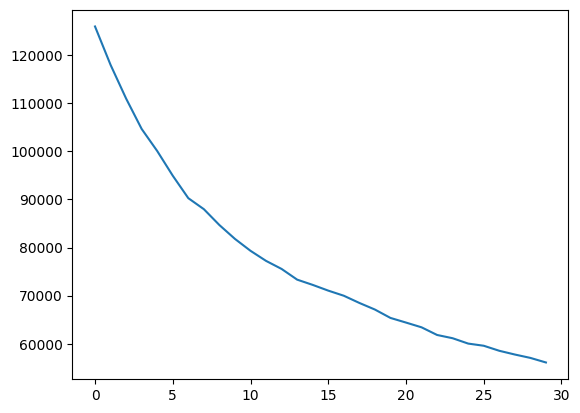

[2369781, 2332550, 2375583, 2357297, 2316799, 2357576, 2332497, 2300156, 2340512, 2305464, 2301806, 2345172, 2529624, 2449694, 2440835, 2451442, 2474505, 2406068, 2403898, 2417595]
(3.0, 7.0)


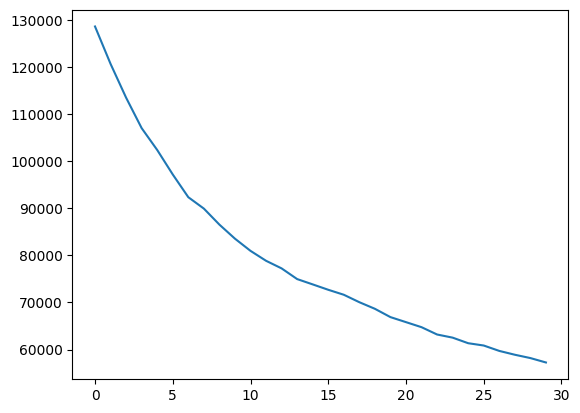

[2408643, 2368333, 2411494, 2396188, 2352711, 2393310, 2371052, 2335981, 2376241, 2343603, 2337725, 2381248, 2570911, 2489127, 2479598, 2490098, 2514532, 2444363, 2441682, 2455599]
(3.0, 7.0)


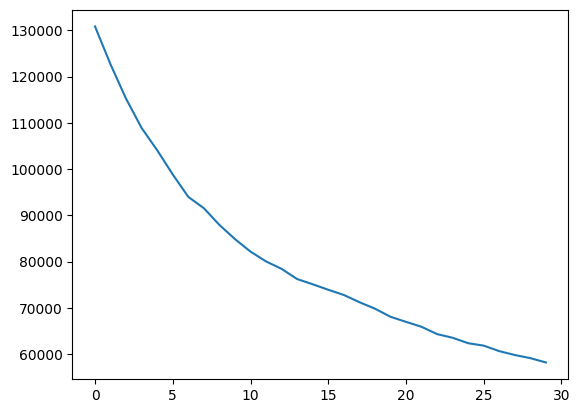

[2448165, 2408456, 2453094, 2435362, 2392794, 2434963, 2410193, 2375889, 2417692, 2382472, 2377555, 2422557, 2613123, 2530939, 2522062, 2533035, 2555151, 2484928, 2483025, 2497488]
(3.0, 7.0)


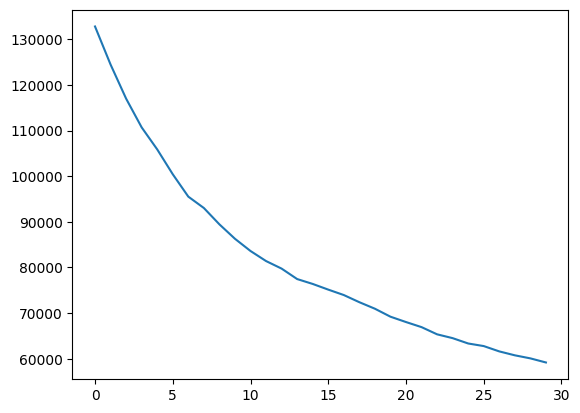

[2490659, 2450262, 2495641, 2477776, 2434592, 2477335, 2452305, 2417457, 2459836, 2423714, 2418383, 2463862, 2660819, 2577109, 2567590, 2578447, 2600815, 2529321, 2526944, 2541362]
(3.0, 7.0)


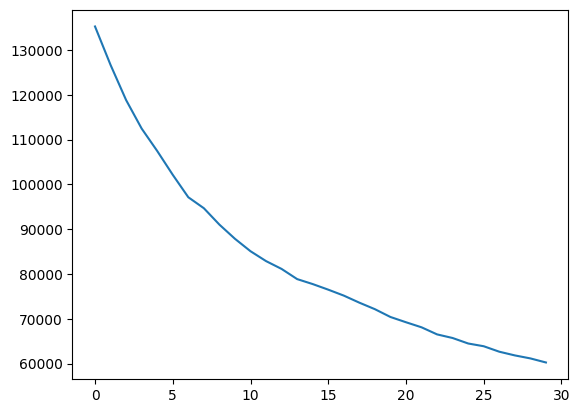

[2545917, 2507465, 2554418, 2533260, 2491434, 2535793, 2507419, 2474059, 2517687, 2478219, 2474056, 2520809, 2722765, 2637620, 2628378, 2639218, 2660506, 2587942, 2585891, 2600384]
(3.5, 7.0)


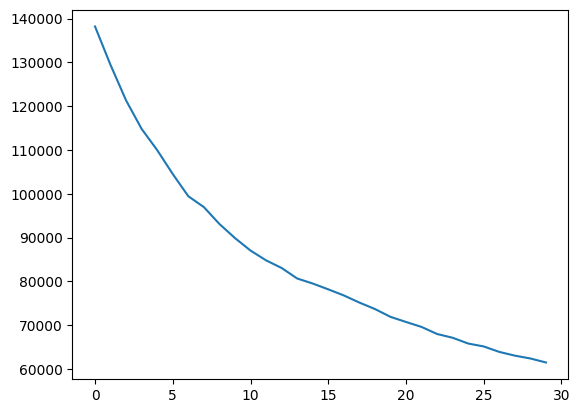

[2600471, 2561091, 2608894, 2587498, 2544701, 2589865, 2561022, 2526769, 2570975, 2531161, 2526624, 2573981, 2781568, 2694864, 2685591, 2696505, 2718348, 2644487, 2642493, 2657196]
(3.5, 7.0)


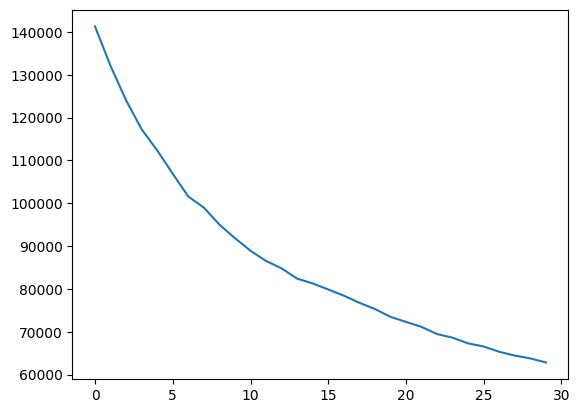

[2667730, 2626396, 2676205, 2653797, 2608673, 2655433, 2625514, 2589035, 2634453, 2593710, 2588264, 2636321, 2854026, 2765085, 2755737, 2767068, 2789669, 2713794, 2711861, 2727070]
(3.5, 7.0)


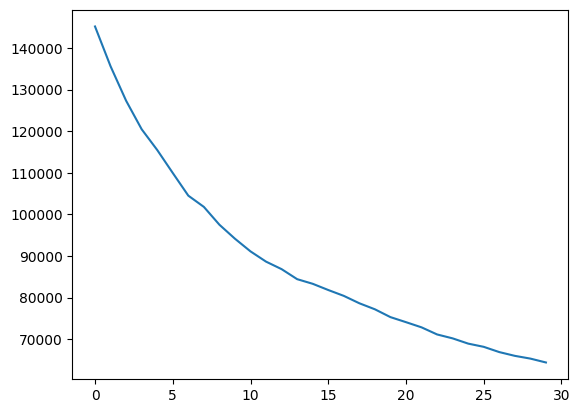

[2723554, 2682435, 2734165, 2709319, 2664458, 2713146, 2680189, 2643839, 2691275, 2646873, 2641934, 2692077, 2914460, 2823993, 2815256, 2827236, 2849332, 2772230, 2771048, 2787014]
(3.5, 7.0)


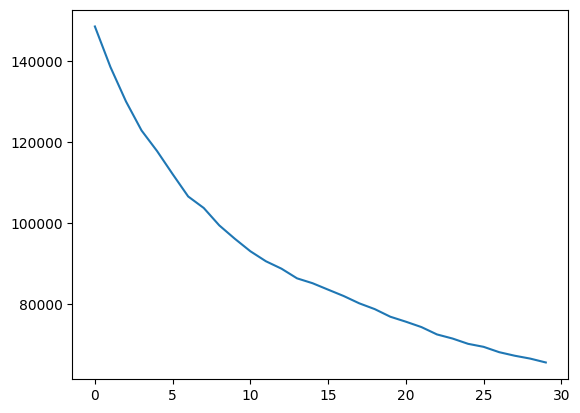

[2782183, 2738241, 2789683, 2767641, 2720115, 2768378, 2737946, 2699150, 2746269, 2704264, 2697214, 2747125, 2979949, 2886341, 2876144, 2887706, 2913638, 2833489, 2830892, 2846343]
(3.5, 7.0)


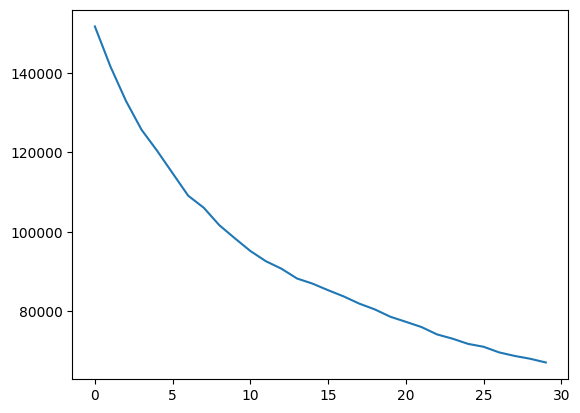

[2840981, 2793713, 2845313, 2825897, 2775272, 2823760, 2795215, 2753637, 2801163, 2759551, 2750733, 2801451, 3045797, 2947638, 2935681, 2947083, 2978009, 2893431, 2889334, 2904768]
(3.5, 7.0)


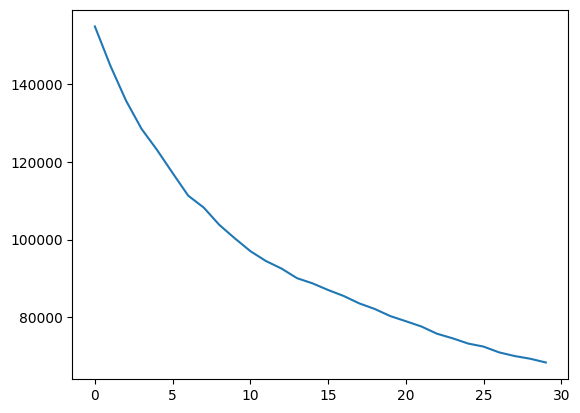

[2887794, 2840293, 2893386, 2872098, 2820818, 2870484, 2840480, 2798044, 2846749, 2803605, 2794210, 2845736, 3096368, 2997019, 2985231, 2997018, 3027198, 2941593, 2937897, 2953772]
(3.5, 7.0)


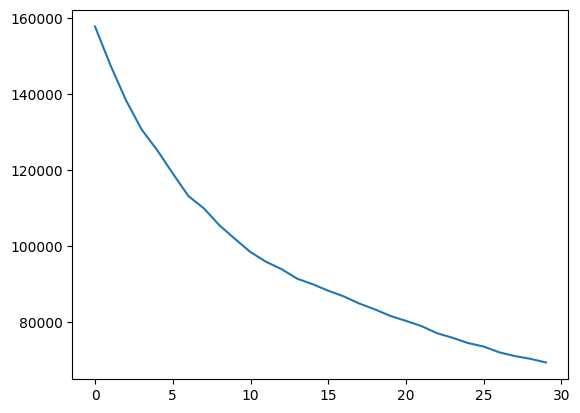

[2949546, 2900929, 2953630, 2933880, 2881638, 2930922, 2901933, 2858702, 2906920, 2865182, 2854765, 2905688, 3160011, 3058825, 3046027, 3057535, 3089654, 3002355, 2997795, 3013384]
(3.5, 7.0)


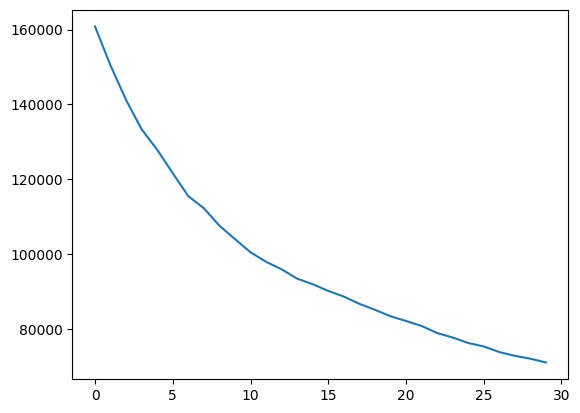

[3009565, 2960546, 3013988, 2993817, 2941290, 2991087, 2961884, 2918432, 2967107, 2925263, 2914954, 2966249, 3225759, 3122813, 3109527, 3121080, 3153970, 3065198, 3060343, 3076105]
(3.5, 7.0)


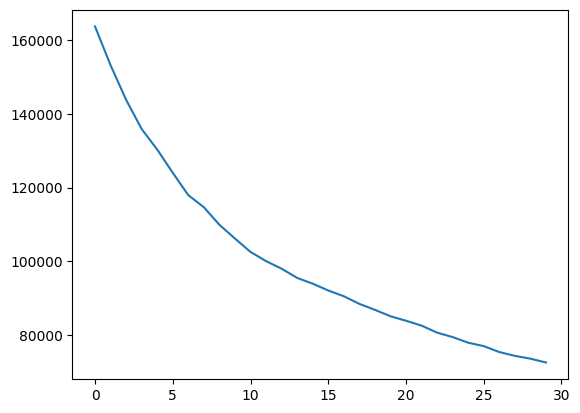

In [183]:
random.seed(42)
fun_lst = []
fun_name = []
# 3.7, 6.4 is best
lowlst = list(np.arange(2.5,3.6,1.0))
highlst = list(np.arange(6.5,7.6,1.0))
lowlst = [3.5]
highlst = [6.5]
shiftlst = list(np.arange(-2.0,0.1,1.0))
cilst = list(np.arange(1.05,1.46,0.1))
df = generate_dpoints(29, num_samples=500, lowlst = lowlst, highlst = highlst, shiftlst = shiftlst, cilst = cilst)
for low_bound in lowlst:
    for high_bound in highlst:
        for shift_value in shiftlst:
            for ci_value in cilst:
                now_low = round(low_bound,2)
                now_high = round(high_bound,2)
                now_shift = round(shift_value,2)
                now_ci = round(ci_value,2)
                suff = '_' + str(now_low).replace('.', 'x') + '_' + str(now_high).replace('.', 'x') + \
                        '_' + (str(now_shift).replace('.', 'x')).replace('-', 'y') + '_' + str(now_ci).replace('.', 'x')
                lst_a1 = []
                lst_a2 = []
                lst_b = []
                for j in range(1,30):
                    strave = 'logave'+str(j)
                    strstd = 'logavex'+str(j)
                    result = get_median_regression(df, 'median', [strave+suff, strstd+suff])
                    lst_a1.append(result.params[1])
                    lst_a2.append(result.params[2])
                    lst_b.append(result.params[0])
                fun_lst.append(regr_low_up(lst_a1,lst_a2,lst_b,now_low,now_high,now_shift,now_ci))
                fun_name.append(str((now_low,now_high,now_shift,now_ci)))
for i in np.arange(2.6,3.5,0.5):
    for j in np.arange(6.5,8.5,0.5):
        fun_lst.append(low_up_fun(i,j))
        fun_name.append('old_'+str((i,j)))
get_penalty(fun_lst,fun_name)

In [262]:
def get_median_regression(df,y,xlst):
    yxmode = y+' ~ '+xlst[0]
    for i in range(1,len(xlst)):
        yxmode = yxmode + ' + ' + xlst[i]
    model = smf.quantreg(yxmode, df)
    result = model.fit(q=0.5)
    return result
def regr_low_up(lst_a1, lst_a2, lst_b,low,up,shift,ci):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            s3=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,low,up) - shift
            s2 = s2 + now
            s3 = s3 + (abs(now)**ci)
            x1 = s2
            x2 = (s3**(1.0/ci))
            med = lst_a1[s1-1]*x1 + lst_a2[s1-1]*x2 + lst_b[s1-1]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [51]:
def low_up_fun(low,up):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*np.log(100.0)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1 )
            if now<low:
                now=low
            if now>up:
                now=up
            s2 = s2 + now
        bid = int((np.exp(s2/s1)-1.0)/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

In [ ]:
random.seed(42)
fun_lst = []
fun_name = []
# for xgb
lowlst = list(np.arange(2.0,3.6,0.5))
highlst = list(np.arange(6.0,8.1,1.0))
df = generate_dpoints(29, num_samples=10, lowlst = lowlst, highlst = highlst)
for low_bound in lowlst:
    for high_bound in highlst:
        now_low = round(low_bound,2)
        now_high = round(high_bound,2)
        lst_b = []
        for j in range(1,30):
            strave = 'logave'+str(j)
            strstd = 'logstd'+str(j)
            suff = '_' + str(now_low).replace('.', '_') + '_' + str(now_high).replace('.', '_')
            result = get_xgboost_regression(df, 'median', [strave+suff, strstd+suff])
            lst_b.append(result)
        fun_lst.append(xgb_low_up(lst_b,now_low,now_high))
        fun_name.append(str((now_low,now_high)))
for i in np.arange(2.6,3.5,0.5):
    for j in np.arange(6.5,8.5,0.5):
        fun_lst.append(low_up_fun(i,j))
        fun_name.append('old_'+str((i,j)))
get_penalty(fun_lst,fun_name)

In [250]:
def get_xgboost_regression(df,y,xlst):
    sX = df[xlst]
    sY = df[y]
    dtrain = xgb.DMatrix(sX.values, label=sY.values)
    params = {
        'objective': 'reg:absoluteerror',
        'max_depth': 2,
        'eta': 0.1,
        'verbosity': 1
    }
    num_rounds = 100
    model = xgb.train(params, dtrain, num_rounds)
    return model
def xgb_low_up(model_lst,low,up):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            s3=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,low,up)
            s2 = s2 + now
            s3 = s3 + now*now
            x1 = s2
            x2 = s3
            dtx = xgb.DMatrix(np.array([x1,x2]).reshape((1,-1)))
            med = model_lst[s1-1].predict(dtx)[0]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [118]:
def regr2(lst_a1, lst_a2, lst_b):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            s3=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,3.1,7.5)
            s2 = s2 + now
            s3 = s3 + now*now
            x1 = s2/s1
            x2 = s3/s1
            x2=np.sqrt(x2)
            med = lst_a1[s1-1]*x1 + lst_a2[s1-1]*x2 + lst_b[s1-1]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [108]:
def regr(lst_a,lst_b):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=0
            s2=0.0
            bid = int(14)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1.0 )
            now = apply_bounds(now,3.1,7.5)
            s2 = s2 + now
            med = s2/s1
            med = lst_a[s1-1]*med+lst_b[s1-1]
            bid = int((np.exp(med)-1.0)/7 + 0.5)
        return (bid,s1,s2,s3)
    return f

In [49]:
def fun_sigmoid( sc  ):
    def f(last_total_bid,last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*0.5
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1 )
            now=1.0/(1.0+np.exp(  (now-np.log(101))*sc  ))
            s2 = s2 + now
        med = s2/s1
        med = np.exp(   (np.log( 1.0/med - 1.0 )/sc) + np.log(101)   ) - 1
        bid = int((med)/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

In [50]:
def upci(up,offset,ci):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*((offset+min(100.0,up))**ci)
        else:
            s1 = s1 + 1
            now = last_yield
            if now>up:
                now=up
            now = now + offset
            now = now ** ci
            s2 = s2 + now
        med = (s2/s1)**(1.0/ci)
        med = med-offset
        bid = int(med/7 - 0.5)
        return (bid,s1,s2,s3)
    return f

[6310, 6311, 6309, 6292, 6295, 6298, 4349]
[278886, 278057, 279385, 278386, 278795, 279544, 571653]


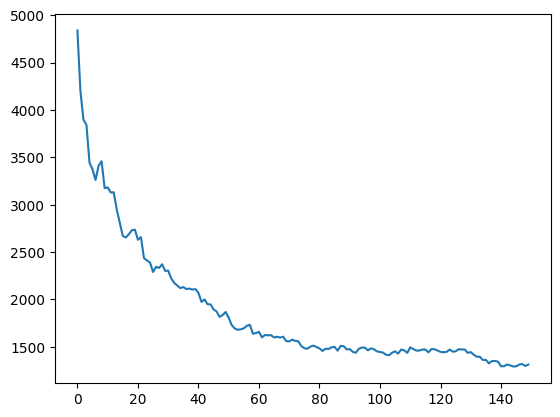

[19661, 19622, 19662, 19683, 19635, 19581, 15080]
[652455, 651966, 652812, 651013, 651957, 655779, 1276590]


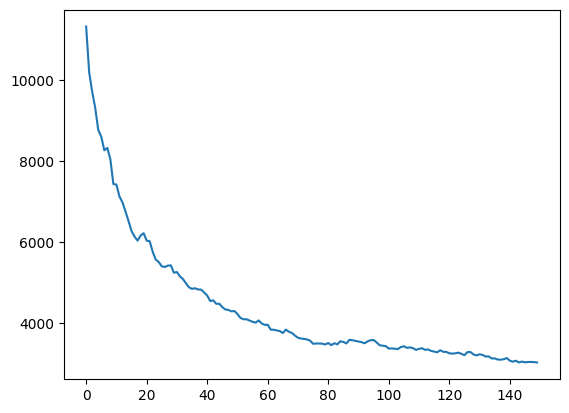

[29411, 29308, 29463, 29453, 29395, 29206, 22017]
[988059, 989508, 988251, 986421, 987353, 996632, 1983585]


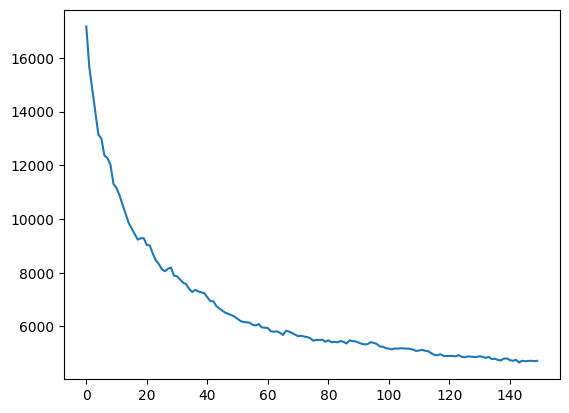

[32427, 32236, 32482, 32476, 32406, 32229, 23696]
[1256177, 1261826, 1256584, 1255192, 1255860, 1272811, 2517824]


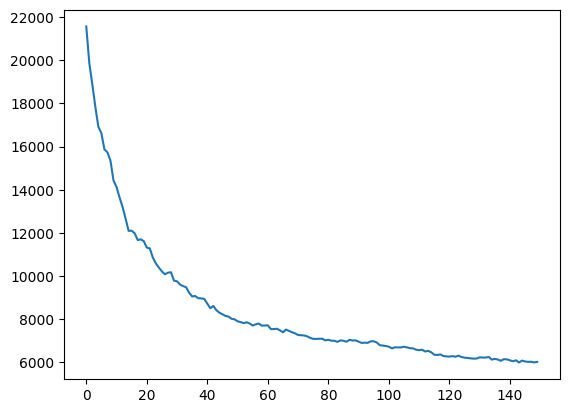

[49993, 49862, 50097, 50084, 49995, 49753, 38162]
[1591491, 1600566, 1592297, 1591838, 1591587, 1612925, 3205142]


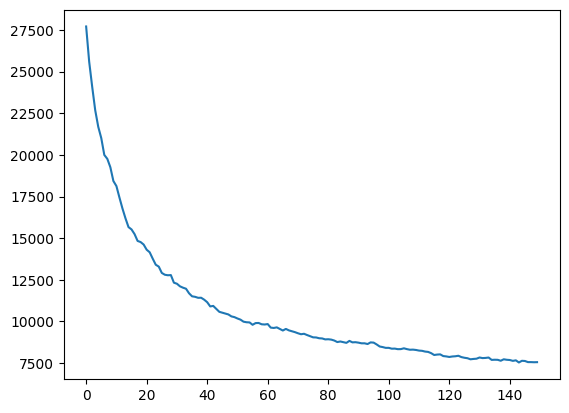

[62819, 62718, 62874, 62920, 62815, 62643, 46373]
[1927467, 1935558, 1928546, 1927408, 1927363, 1949107, 3951947]


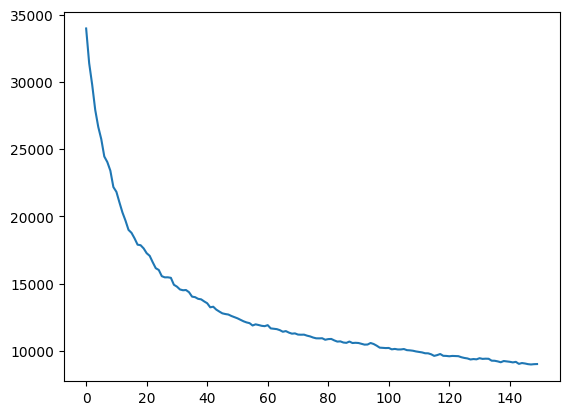

In [320]:
#player_lst = [st2] + [st3] + [st4] + [naive_strategy] * 4
random.seed(42)
player_lst = [low_up_fun(3.15,7.4)] +[low_up_fun(3.0,8.0)]+[low_up_fun(3.2,7.4)]+[low_up_fun(3.1,7.55)] +\
                 [low_up_fun(3.15,7.45)] + [low_up_fun(2.8,8.0)]  + [naive_strategy]
#player_lst = [naive_strategy]*7
Simulation(player_lst)

In [52]:
def st6(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
    else:
        s1 = s1 + 1
        now = np.log( last_yield+1 )
        if now<2.0:
            now=2.0
        #if now>6.2:
        #    now=6.2
        s2 = s2 + now
    bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [53]:
def st4( last_total_bid, last_yield, s1, s2, s3):
    shft = 0
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
        s3=0
    else:
        if last_total_bid > 1.2* (np.exp(s2/s1)):
            if s3<0:
                s3=1
            else:
                s3 = s3+1
        if last_total_bid < 0.8* (np.exp(s2/s1)):
            if s3>0:
                s3=-1
            else:
                s3 = s3-1
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
    if s3>3:
        shft = s3-3
    if s3<-3:
        shft = s3+3
    bid = int((np.exp(s2/s1))/7 - 0.5 - shft)
    return (bid,s1,s2,s3)

In [54]:
def st3(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        s1=5
        s2=5.0*np.log(100.0)
    else:
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
    bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [55]:
def st2(last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        bid = 14
        s1=0
        s2=0.0
    else:
        s1 = s1 + 1
        s2 = s2 + np.log( last_yield+1 )
        bid = int((np.exp(s2/s1))/7 - 0.5)
    return (bid,s1,s2,s3)

In [56]:
from random import randint
def st5(last_total_bid, last_yield, s1, s2, s3):
    bid=14
    if last_yield == -1:
        s1=-1
        s2=-1
        s3=-1
    elif s1==-1:
        s1=last_yield
    elif s2==-1:
        s2=last_yield
    elif s3==-1:
        s3=last_yield
    else:
        lst = [s1,s2,s3,last_yield]
        sorted_lst = sorted(lst)
        bid = int((s2)/7+0.5)
        x = randint(1,4)
        if x==1:
            s1=last_yield
        if x==2:
            s2=last_yield
        if x==3:
            s3=last_yield
        
        
    return (bid,s1,s2,s3)

In [57]:
def naive_strategy( last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        bid = 14
    elif last_total_bid<=last_yield:
        bid = s1+1
    else:
        bid = s1-1
    if bid<0:
        bid = 0
    s1 = bid
    return (bid,s1,s2,s3)

In [58]:
def st1( last_total_bid, last_yield, s1, s2, s3):
    bid = 14
    return (bid,s1,s2,s3)

In [69]:
sample_median([11,11,10,9,8])

74.0

In [68]:
for i1 in range(8,9):
    for i2 in range(i1,11):
        for i3 in range(i2,12):
            for i4 in range(i3,13):
                for i5 in range(i4,14):
                    v = get_median_by_ywlst([i5,i4,i3,i2,i1])
                    if v==74:
                        print([i5,i4,i3,i2,i1])

[10, 8, 8, 8, 8]
[13, 12, 9, 9, 8]
[13, 10, 10, 9, 8]
[11, 11, 10, 9, 8]
